# Semantic segmantation

- U-Net을 통한 세그멘테이션 작업이 정상적으로 진행되었는가?  
&rarr; KITTI 데이터셋 구성, U-Net 모델 훈련, 결과물 시각화의 한 사이클이 정상 수행되어 세그멘테이션 결과 이미지를 제출하였다.  
- U-Net++ 모델이 성공적으로 구현되었는가?  
&rarr; U-Net++ 모델을 스스로 구현하여 학습 진행 후 세그멘테이션 결과까지 정상 진행되었다.  
- U-Net과 U-Net++ 두 모델의 성능이 정량적/정성적으로 잘 비교되었는가?  
&rarr; U-Net++ 의 세그멘테이션 결과 사진과 IoU 계산치를 U-Net과 비교하여 우월함을 확인하였다.  

# 0. 라이브러리 import & setting

In [1]:
import os
from glob import glob # 파일, 디렉터리 찾을 때 사용
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread # 이미지 파일 불러서 numpy array로 변환 (H, W, C), C: RGB
from skimage.transform import resize

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from albumentations import HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

/home/minkyujeong/anaconda3/envs/nlp_cv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = os.path.join(os.getcwd(), "data/training")
print(DATA_DIR)
SAVE_DIR = os.path.join(os.getcwd(), "models")
print(SAVE_DIR)

/home/minkyujeong/work/DeepDive/ch3_semantic_seg/data/training
/home/minkyujeong/work/DeepDive/ch3_semantic_seg/models


In [3]:
BATCH_SIZE = 16
LR = 1e-4
EPOCHS = 100


# 1. 데이터셋 준비 (KITTI 데이터셋 구성)

In [4]:
# data augmentation 수행 함수
def augment_data(is_train=True): # 학습 데이터만 True
    if is_train: # 학습 데이터일 때 augmentation
        return Compose([
            HorizontalFlip(p=0.5), # 0.5의 확률로 h-flip
            RandomSizedCrop(                
                min_max_height=(300,370), # 높이를 300~370 중 선택
                w2h_ratio=1242/370, # h에 대한 w 비율
                # h:2, w:1 이면 w2h는 0.5, h:4가 되면 w = 4 * 0.5 = 2
                # 원본 이미지에서 h:370, w:1242 -> new_w = new_h * w2h
                size=(224, 224), # h, w
                p=0.5
            ),
            # RandomSizedCrop의 resize는 0.5 확률로 작동해서
            Resize(width=224, height=224)
        ])
    else: # 테스트 데이터는 resize만
        return Compose([Resize(width=224, height=224)])

In [5]:
class KittiDataset(Dataset):
    def __init__(self, data_path, img_size=(224,224,3), out_size=(224,224), is_train=True, aug=None):
        '''
        data_path: data 디렉터리 path
        img_size: preprocess에 사용할 입력 이미지의 크기
        out_size: ground truth를 만들어주기 위한 크기
        is_trian: 학습용인지 구분
        aug: 적용하려는 augmentation 함수
        '''
        super().__init__()
        self.data_path = data_path
        self.img_size = img_size
        self.out_size = out_size,
        self.is_train = is_train
        self.aug = aug

        # load_data를 통해 KITTI dataset의 경로에서 이미지, 라벨 확인
        self.data = self.load_data()

    def load_data(self):
        # KITTI dataset에서 필요한 정보(이미지 경로, 라벨 경로)를 실제 디렉터리에서 확인하고 load
        img_paths = sorted(glob(os.path.join(self.data_path, "image_2", "*.png")))
        label_paths = sorted(glob(os.path.join(self.data_path, "semantic", "*.png")))

        assert len(img_paths) == len(label_paths), print("이미지, 라벨 개수를 확인하세요..")
        data = list(zip(img_paths, label_paths))

        if self.is_train: # train data 일 때 
            return data[:-30] # 전체 데이터에서 30개 빼고 train data
        return data[-30:] # 30개는 validation data
    
    def __len__(self): # dataset 개수
        return len(self.data)
    
    def __getitem__(self,idx):
        # image와 label을 반환
        # image는 resize 및 augmentation 적용된 image
        # label은 resize만 적용한 semantic image
        img_path, label_path = self.data[idx]

        _img = imread(img_path) # numpy.ndarray (H, W, C), 0~255 값 
        _label = imread(label_path) # numpy.ndarray (H, W), 0~255값 
        
        # 도로에 해당하는 라벨을 마스크로 변환 (uint8: 0~255)
        _label = (_label == 7).astype(np.uint8) * 1 # 도로에 해당하는 픽셀은 1, 아니면 0인 이미지가 됨
        
        data = {'image': _img, 'mask': _label}
        
        # aug 적용
        if self.aug: # train은 여러 augmentation, test는 resize만
            augmented = self.aug(**data)
            _img = augmented['image'] / 255.0 # normalize
            _label = augmented['mask'] # 1 or 0
        
        # 마스크는 1채널이라 2차원 데이터로 존재함 (image는 3차원)
        # 마스크 차원 확장 (H, W) -> (C, H, W)
        _label = np.expand_dims(_label, axis=0)

        # torch.tensor로 변환한 후 tuple로 반환
        return (torch.tensor(_img, dtype=torch.float32).permute(2,0,1), # (H, W, C) -> (C, H, W)
                torch.tensor(_label, dtype=torch.float32)) # (1, H, W)
    
    def shuffle_data(self):
        # 한 에폭이 끝나면 실행 (학습 중인 경우, 데이터를 random shuffle)
        if self.is_train:
            np.random.shuffle(self.data)

In [6]:
sample_img_path = glob(os.path.join(DATA_DIR, "image_2", "*.png"))
sample_path = glob(os.path.join(DATA_DIR, "semantic", "*.png"))
sample_path[0]

'/home/minkyujeong/work/DeepDive/ch3_semantic_seg/data/training/semantic/000042_10.png'

In [7]:
# a_img = imread(sample_img_path[0])
# print(a_img.dtype)
# print(a_img)

In [8]:
# # type(imread(sample_path[0]))
# a = imread(sample_path[0])
# print(a)
# (a == 7).astype(np.uint8)


In [9]:
# train, test 각각에 대한 preprocess 할당
train_aug = augment_data()
test_aug = augment_data(is_train=False)

train_dataset = KittiDataset(DATA_DIR, is_train=True, aug=train_aug)
test_dataset = KittiDataset(DATA_DIR, is_train=False, aug=test_aug)

In [10]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. 모델 정의

## 2.1. UNet

In [54]:
class UNet(nn.Module):
    def __init__(self, in_chs=3, out_chs=1, n_filters=[32, 64, 128, 256, 512]):
        super().__init__()

        # 각 단계(Depth)별 채널 수 설정
        self.n_filters = n_filters
        # self.n_filters = [64, 128, 256, 512, 1024]

        # Contracting path (Encoder)
        self.enc1 = self.double_conv(in_chs, self.n_filters[0])
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(self.n_filters[0], self.n_filters[1])
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(self.n_filters[1], self.n_filters[2])
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(self.n_filters[2], self.n_filters[3])
        self.pool4 = nn.MaxPool2d(2)

        # bottleneck
        self.bottleneck = self.double_conv(self.n_filters[3], self.n_filters[4])
        self.dropout = nn.Dropout(0.5)

        # Expanding path (Decoder)
        self.up1 = nn.ConvTranspose2d(self.n_filters[4], self.n_filters[3], kernel_size=2, stride=2) # 이미지 사이즈 2배 (sride=2)
        self.dec1 = self.double_conv(self.n_filters[4], self.n_filters[3]) # up에서 512로 줄어도, concat해서 다시 1024로 늘어나므로
        self.up2 = nn.ConvTranspose2d(self.n_filters[3], self.n_filters[2], kernel_size=2, stride=2)
        self.dec2 = self.double_conv(self.n_filters[3], self.n_filters[2])
        self.up3 = nn.ConvTranspose2d(self.n_filters[2], self.n_filters[1], kernel_size=2, stride=2)
        self.dec3 = self.double_conv(self.n_filters[2], self.n_filters[1])
        self.up4 = nn.ConvTranspose2d(self.n_filters[1], self.n_filters[0], kernel_size=2, stride=2)
        self.dec4 = self.double_conv(self.n_filters[1], self.n_filters[0])

        # output layer
        self.final_conv = nn.Conv2d(self.n_filters[0], out_chs, kernel_size=1) # 1x1 conv


    def double_conv(self, in_chs, out_chs):
        # 2개의 conv layer로 이루어진 block을 반환
        return nn.Sequential(
            nn.Conv2d(in_chs, out_chs, kernel_size=3, padding=1), # 이미지 사이즈 유지
            nn.ReLU(inplace=True),
            nn.Conv2d(out_chs, out_chs, kernel_size=3, padding=1), # 이미지 사이즈 유지
            nn.ReLU(inplace=True),
        )
    
    def up_pad(self, smaller_tensor, bigger_tensor):
        diff_w = bigger_tensor.shape[-1] - smaller_tensor.shape[-1]
        diff_h = bigger_tensor.shape[-2] - smaller_tensor.shape[-2]
        # [좌, 우, 상, 하] 순서로 채워줘야 함
        padded_tensor = F.pad(smaller_tensor, [diff_w // 2, diff_w - (diff_w // 2),
                                               diff_h // 2, diff_h - (diff_h // 2)])
        return padded_tensor
    
    def forward(self, x):
        # Encoder
        c1 = self.enc1(x) # in_chs(3) -> 64
        p1 = self.pool1(c1)
        c2 = self.enc2(p1) # 64 -> 128
        p2 = self.pool2(c2)
        c3 = self.enc3(p2) # 128 -> 256
        p3 = self.pool3(c3)
        c4 = self.enc4(p3) # 256 -> 512
        p4 = self.pool4(c4)

        # bottleneck
        c5 = self.bottleneck(p4) # 512 -> 1024
        c5 = self.dropout(c5)

        # Decoder
        exp4 = self.up1(c5) # 1024 -> 512
        exp4 = self.up_pad(exp4, c4) if exp4.shape[-2:] < c4.shape[-2:] else exp4 # 이미지 사이즈 작으면 up_pad 적용
        exp4 = torch.concat([exp4, c4], dim=1) # 512+512 -> 1024, 채널 차원에서 concat
        d4 = self.dec1(exp4) # 1024 -> 512
        
        exp3 = self.up2(d4) # 512 -> 256
        exp3 = self.up_pad(exp3, c3) if exp3.shape[-2:] < c3.shape[-2:] else exp3
        exp3 = torch.concat([exp3, c3], dim=1) # 256+256 -> 512
        d3 = self.dec2(exp3) # 512 -> 256

        exp2 = self.up3(d3) # 256 -> 128
        exp2 = self.up_pad(exp2, c2) if exp2.shape[-2:] < c2.shape[-2:] else exp2
        exp2 = torch.concat([exp2, c2], dim=1) # 128+128 -> 256
        d2 = self.dec3(exp2) # 256 -> 128

        exp1 = self.up4(d2) # 128 -> 64
        exp1 = self.up_pad(exp1, c1) if exp1.shape[-2:] < c1.shape[-2:] else exp1
        exp1 = torch.concat([exp1, c1], dim=1) # 64+64 -> 128
        d1 = self.dec4(exp1)

        out = self.final_conv(d1) # 64 -> out_chs(1)
        out = F.sigmoid(out) # (N, C, H, W) 각 값을 0~1로 만들어서 mask 해당 여부 보려고
        
        return out


In [55]:
# model = UNet(3, 1)
# ex_data = torch.randn((4,3,572,572))
# model(ex_data).shape

## 2.2. UNet++

In [56]:
# 2. UNet++ 메인 모델
class UNetPP(nn.Module):
    def __init__(self, in_chs=3, out_chs=1, n_filters=[32, 64, 128, 256, 512], deep_supervision=False):
        super().__init__()
        self.deep_supervision = deep_supervision
        
        # 각 단계(Depth)별 채널 수 설정
        self.n_filters = n_filters
        # self.n_filters = [64, 128, 256, 512, 1024]

        self.pool = nn.MaxPool2d(2)
        # ConvTranspose2d 사용 안 함 (노이즈, 연산량 문제)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        # 모듈 정의 (행렬의 각 노드에 해당하는 연산 블록 생성)
        
        # j=0 (원래 UNet의 인코더 부분)
        self.conv0_0 = self.double_conv(in_chs, self.n_filters[0]) # 3 -> n_filters[0]: 64
        self.conv1_0 = self.double_conv(self.n_filters[0], self.n_filters[1]) # n_filters[0]: 64 -> n_filters[1]: 128
        self.conv2_0 = self.double_conv(self.n_filters[1], self.n_filters[2]) # n_filters[0]: 128 -> n_filters[1]: 256
        self.conv3_0 = self.double_conv(self.n_filters[2], self.n_filters[3]) # n_filters[0]: 256 -> n_filters[1]: 512
        self.conv4_0 = self.double_conv(self.n_filters[3], self.n_filters[4]) # n_filters[0]: 512 -> n_filters[1]: 1024

        # j=1
        # 입력 채널: 이전 노드(j=0)의 채널 + 아래층(i+1)에서 올라온 채널
        self.conv0_1 = self.double_conv(self.n_filters[0] + self.n_filters[1], self.n_filters[0]) # 64 + 128 -> 64
        self.conv1_1 = self.double_conv(self.n_filters[1] + self.n_filters[2], self.n_filters[1]) # 128 + 256 -> 128
        self.conv2_1 = self.double_conv(self.n_filters[2] + self.n_filters[3], self.n_filters[2]) # 256 + 512 -> 256
        self.conv3_1 = self.double_conv(self.n_filters[3] + self.n_filters[4], self.n_filters[3]) # 512 + 1024 -> 512

        # j=2 (Dense Connection 시작)
        # 입력 채널: 이전 노드 2개(j=0, j=1)의 채널 + 아래층에서 올라온 채널
        self.conv0_2 = self.double_conv(self.n_filters[0]*2 + self.n_filters[1], self.n_filters[0]) # 64*2 
        self.conv1_2 = self.double_conv(self.n_filters[1]*2 + self.n_filters[2], self.n_filters[1])
        self.conv2_2 = self.double_conv(self.n_filters[2]*2 + self.n_filters[3], self.n_filters[2])

        # j=3
        self.conv0_3 = self.double_conv(self.n_filters[0]*3 + self.n_filters[1], self.n_filters[0])
        self.conv1_3 = self.double_conv(self.n_filters[1]*3 + self.n_filters[2], self.n_filters[1])

        # j=4 (최종 디코더 끝단)
        self.conv0_4 = self.double_conv(self.n_filters[0]*4 + self.n_filters[1], self.n_filters[0])


        # 출력 레이어 (Deep Supervision용)
        self.final1 = nn.Conv2d(self.n_filters[0], out_chs, kernel_size=1)
        self.final2 = nn.Conv2d(self.n_filters[0], out_chs, kernel_size=1)
        self.final3 = nn.Conv2d(self.n_filters[0], out_chs, kernel_size=1)
        self.final4 = nn.Conv2d(self.n_filters[0], out_chs, kernel_size=1)

    def double_conv(self, in_chs, out_chs):
        # 2개의 conv layer로 이루어진 block을 반환
        return nn.Sequential(
            nn.Conv2d(in_chs, out_chs, kernel_size=3, padding=1), # 이미지 사이즈 유지
            nn.BatchNorm2d(out_chs),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_chs, out_chs, kernel_size=3, padding=1), # 이미지 사이즈 유지
            nn.BatchNorm2d(out_chs),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        # 순전파 (행렬 X^{i,j} 규칙에 따른 노드 계산)      
        
        # Column 0 (Encoder)
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))

        # Column 1
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], dim=1))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], dim=1))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], dim=1))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0)], dim=1))

        # Column 2
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], dim=1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], dim=1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], dim=1))

        # Column 3
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], dim=1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], dim=1))

        # Column 4
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], dim=1))

        
        # 결과 반환 (Deep Supervision 분기)        
        if self.deep_supervision:
            # 학습 시: 중간 노드들의 결과도 모두 반환하여 각각 Loss 계산
            out1 = F.sigmoid(self.final1(x0_1))
            out2 = F.sigmoid(self.final2(x0_2))
            out3 = F.sigmoid(self.final3(x0_3))
            out4 = F.sigmoid(self.final4(x0_4))
            return [out1, out2, out3, out4]
        else:
            # 추론 시: 가장 마지막 노드의 결과만 반환
            return F.sigmoid(self.final4(x0_4))



In [14]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):        
        
        inputs = inputs.view(-1) # 모든 픽셀을 봐야 하니까 하나의 차원으로 == flatten()
        targets = targets.view(-1)
        
        # Dice Loss 계산
        intersection = (inputs * targets).sum() # and 연산 처럼 1*1만 남김(1*0, 0*1은 사라짐)                            
        dice_loss = 1 - (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)  
        
        # BCE Loss 계산
        # reduction='mean'을 사용하여 배치 평균을 구함
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        
        # 두 Loss를 더함 (비중은 1:1이 일반적)
        return 0.5*BCE + dice_loss

In [15]:
# model_pp = UNetPP(3, 1)
# # ex_data = torch.randn((4,3,572,572))
# ex_data = torch.randn((4,3,256,256))
# model_pp(ex_data).shape

# 3. 모델 학습

In [16]:
def train_model(model, epochs, criterion, lr, train_loader, val_loader, save_model_path, model_name, device="cuda"):
    # 결과를 담을 딕셔너리 초기화
    res_dict = {
        'train_losses': [], 'train_accs': [],
        'val_losses': [], 'val_accs': []
    }
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_loss = float('inf') # 무한대로 초기화
    
    model.to(device)

    for epoch in range(epochs):
        # ================= [ Training ] =================
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:        
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            
            # 1. UNet++ Deep Supervision(리스트 출력) vs 일반 UNet(단일 출력) 대응
            if isinstance(outputs, list):
                # 여러 개의 출력(out1~out4)에 대해 각각 Loss를 구하고 평균(또는 합)을 냅니다.
                loss = 0.0
                for out in outputs:
                    loss += criterion(out, labels)
                loss /= len(outputs) # 평균을 내어 스케일 유지
                
                final_output = outputs[-1] # 정확도 계산은 가장 마지막 출력 노드(out4)로 진행
            else:
                loss = criterion(outputs, labels)
                final_output = outputs

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            # 2. Pixel Accuracy 계산
            # 모델 출력이 Sigmoid 값이므로 출력값이 0.5보다 크면 1, 작으면 0
            predicted = (final_output > 0.5).float() 
            
            # shape 불일치(예: [B, 1, H, W] vs [B, H, W])로 인한 브로드캐스팅 에러 방지
            predicted = predicted.view(-1)
            labels_flat = labels.view(-1)
            
            correct += (predicted == labels_flat).sum().item()
            total += labels_flat.numel() # len(labels) 대신 전체 픽셀 수(numel)를 더함
        
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = correct / total
        res_dict['train_losses'].append(epoch_train_loss)
        res_dict['train_accs'].append(epoch_train_acc)

        # ================= [ Validation ] =================
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                
                # 평가(Eval) 시에는 UNet++도 마지막 결과 하나만 반환하도록 세팅하거나, 
                # 리스트가 나오더라도 마지막 것만 사용
                if isinstance(outputs, list):
                    final_output = outputs[-1]
                    loss = criterion(final_output, labels)
                else:
                    final_output = outputs
                    loss = criterion(final_output, labels)

                val_loss += loss.item()
                
                predicted = (final_output > 0.5).float()
                predicted = predicted.view(-1)
                labels_flat = labels.view(-1)

                val_correct += (predicted == labels_flat).sum().item()
                val_total += labels_flat.numel()

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = val_correct / val_total
        res_dict['val_losses'].append(epoch_val_loss)
        res_dict['val_accs'].append(epoch_val_acc)

        # ================= [ Checkpoint Save ] =================
        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            # 3. optimizer 객체 대신 state_dict()를 저장
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch + 1,
                "best_loss": best_loss
            }, save_model_path + "/best_" + model_name + ".pt")
        
        # 출력
        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] " 
                f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc*100:.2f}% | "
                f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc*100:.2f}%")
        
    print("-" * 50)
    print("Training has been finished...")
    best_idx = res_dict['val_losses'].index(best_loss)
    print(f"Best Validation Loss: {best_loss:.4f}, -> Acc: {res_dict['val_accs'][best_idx]*100:.2f}")
    
    return res_dict

In [17]:
def plot_history(history):
    epochs = range(1, len(history['train_losses']) + 1)

    plt.figure(figsize=(12, 5))

    # 1. Loss 그래프 (왼쪽)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_losses'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_losses'], 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xticks(epochs)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Accuracy 그래프 (오른쪽)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_accs'], 'b-', label='Train Acc')
    plt.plot(epochs, history['val_accs'], 'r-', label='Validation Acc')    
    plt.title('Training and Validation Accuracy')
    plt.xticks(epochs)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout() # 그래프 간 간격 자동 조절
    plt.show()

## 3.1. UNet

In [18]:
model_unet = UNet(3, 1)
criterion_unet = nn.BCELoss()

In [19]:
res_unet = train_model(model_unet, epochs=EPOCHS, criterion=criterion_unet, lr = LR,
                       train_loader=train_loader, val_loader=test_loader, save_model_path=SAVE_DIR, model_name="unet")

Epoch [10/100] Train Loss: 0.2908, Train Acc: 87.30% | Val Loss: 0.3024, Val Acc: 86.81%
Epoch [20/100] Train Loss: 0.1830, Train Acc: 92.55% | Val Loss: 0.2368, Val Acc: 90.01%
Epoch [30/100] Train Loss: 0.1723, Train Acc: 93.49% | Val Loss: 0.2161, Val Acc: 91.71%
Epoch [40/100] Train Loss: 0.1532, Train Acc: 94.10% | Val Loss: 0.2186, Val Acc: 91.28%
Epoch [50/100] Train Loss: 0.1435, Train Acc: 94.45% | Val Loss: 0.2004, Val Acc: 92.33%
Epoch [60/100] Train Loss: 0.1388, Train Acc: 94.56% | Val Loss: 0.1993, Val Acc: 92.17%
Epoch [70/100] Train Loss: 0.1241, Train Acc: 95.08% | Val Loss: 0.1749, Val Acc: 93.41%
Epoch [80/100] Train Loss: 0.1147, Train Acc: 95.62% | Val Loss: 0.2045, Val Acc: 92.51%
Epoch [90/100] Train Loss: 0.1000, Train Acc: 96.05% | Val Loss: 0.1756, Val Acc: 93.39%
Epoch [100/100] Train Loss: 0.0923, Train Acc: 96.33% | Val Loss: 0.1582, Val Acc: 94.32%
--------------------------------------------------
Training has been finished...
Best Validation Loss: 0.1519

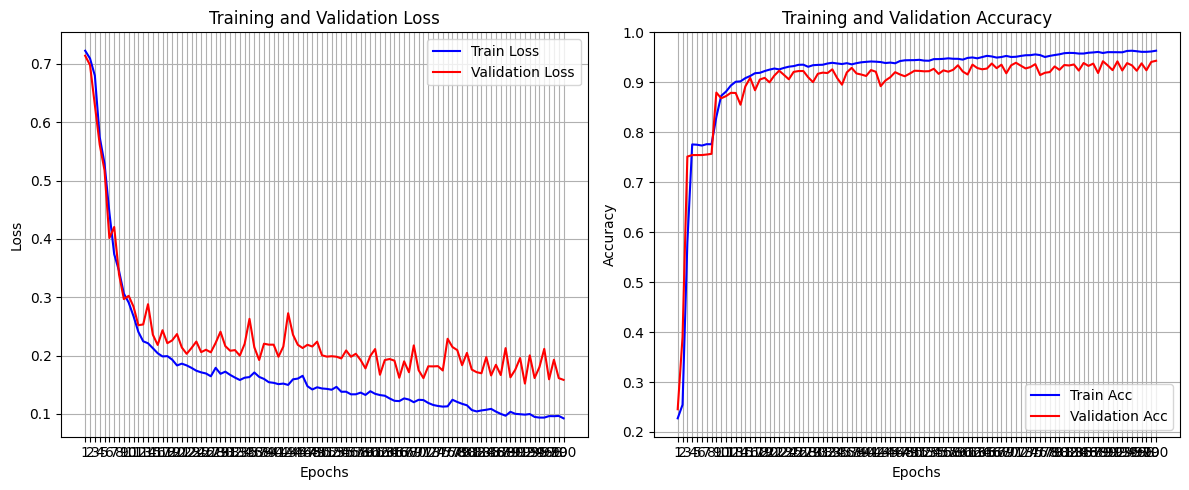

In [20]:
plot_history(res_unet)

## 3.2. Unet++

In [21]:
model_unetpp_bce = UNetPP(3, 1, deep_supervision=True)
criterion_unetpp_bce = nn.BCELoss()

In [22]:
res_unetpp_bce = train_model(model_unetpp_bce, epochs=EPOCHS, criterion=criterion_unetpp_bce, lr = LR,
                            train_loader=train_loader, val_loader=test_loader, save_model_path=SAVE_DIR, model_name="unetpp_bce")

Epoch [10/100] Train Loss: 0.3156, Train Acc: 94.80% | Val Loss: 0.3276, Val Acc: 91.93%
Epoch [20/100] Train Loss: 0.2694, Train Acc: 96.20% | Val Loss: 0.2580, Val Acc: 94.60%
Epoch [30/100] Train Loss: 0.2343, Train Acc: 97.40% | Val Loss: 0.2465, Val Acc: 94.39%
Epoch [40/100] Train Loss: 0.2106, Train Acc: 97.70% | Val Loss: 0.2222, Val Acc: 94.78%
Epoch [50/100] Train Loss: 0.1876, Train Acc: 98.02% | Val Loss: 0.2096, Val Acc: 94.85%
Epoch [60/100] Train Loss: 0.1782, Train Acc: 97.90% | Val Loss: 0.2047, Val Acc: 94.73%
Epoch [70/100] Train Loss: 0.1543, Train Acc: 98.48% | Val Loss: 0.1827, Val Acc: 95.06%
Epoch [80/100] Train Loss: 0.1414, Train Acc: 98.43% | Val Loss: 0.1738, Val Acc: 95.17%
Epoch [90/100] Train Loss: 0.1289, Train Acc: 98.73% | Val Loss: 0.1598, Val Acc: 95.61%
Epoch [100/100] Train Loss: 0.1182, Train Acc: 98.87% | Val Loss: 0.1529, Val Acc: 95.79%
--------------------------------------------------
Training has been finished...
Best Validation Loss: 0.1529

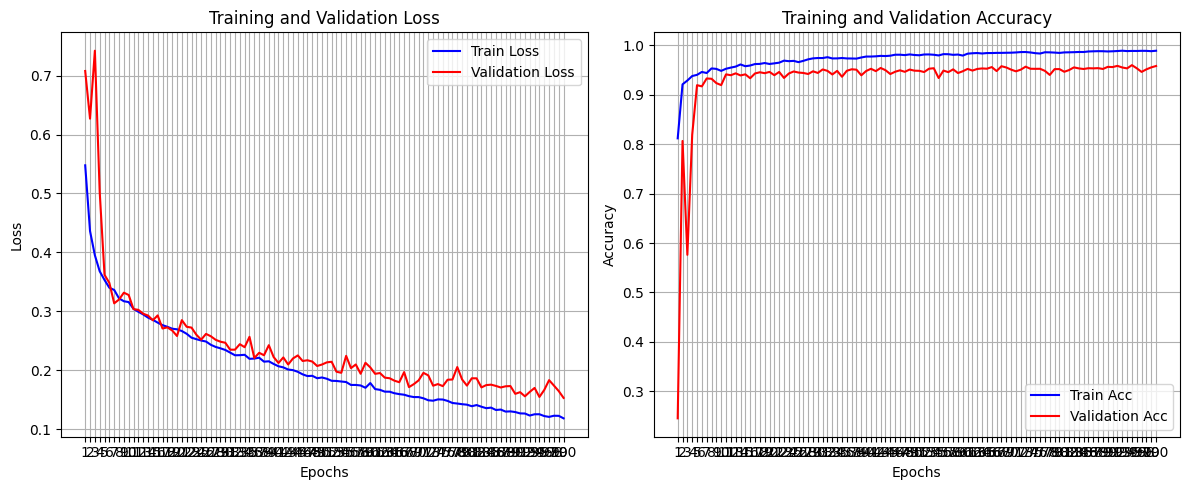

In [23]:
plot_history(res_unetpp_bce)

In [24]:
model_unetpp_dicebce = UNetPP(3, 1, deep_supervision=True)
criterion_unetpp_dicebce = DiceBCELoss()

In [25]:
res_unetpp_dicebce = train_model(model_unetpp_dicebce, epochs=EPOCHS, criterion=criterion_unetpp_dicebce, lr = LR,
                                train_loader=train_loader, val_loader=test_loader, save_model_path=SAVE_DIR, model_name="unetpp_dicebce")

Epoch [10/100] Train Loss: 0.5605, Train Acc: 95.06% | Val Loss: 0.5703, Val Acc: 91.61%
Epoch [20/100] Train Loss: 0.4962, Train Acc: 96.05% | Val Loss: 0.4967, Val Acc: 93.95%
Epoch [30/100] Train Loss: 0.4521, Train Acc: 97.26% | Val Loss: 0.4576, Val Acc: 93.54%
Epoch [40/100] Train Loss: 0.3996, Train Acc: 97.97% | Val Loss: 0.3942, Val Acc: 94.52%
Epoch [50/100] Train Loss: 0.3566, Train Acc: 98.11% | Val Loss: 0.3806, Val Acc: 93.85%
Epoch [60/100] Train Loss: 0.3284, Train Acc: 98.03% | Val Loss: 0.3450, Val Acc: 93.74%
Epoch [70/100] Train Loss: 0.3019, Train Acc: 98.41% | Val Loss: 0.3039, Val Acc: 95.14%
Epoch [80/100] Train Loss: 0.2721, Train Acc: 98.67% | Val Loss: 0.2979, Val Acc: 94.86%
Epoch [90/100] Train Loss: 0.2514, Train Acc: 98.83% | Val Loss: 0.2891, Val Acc: 94.68%
Epoch [100/100] Train Loss: 0.2261, Train Acc: 98.84% | Val Loss: 0.2801, Val Acc: 94.63%
--------------------------------------------------
Training has been finished...
Best Validation Loss: 0.2566

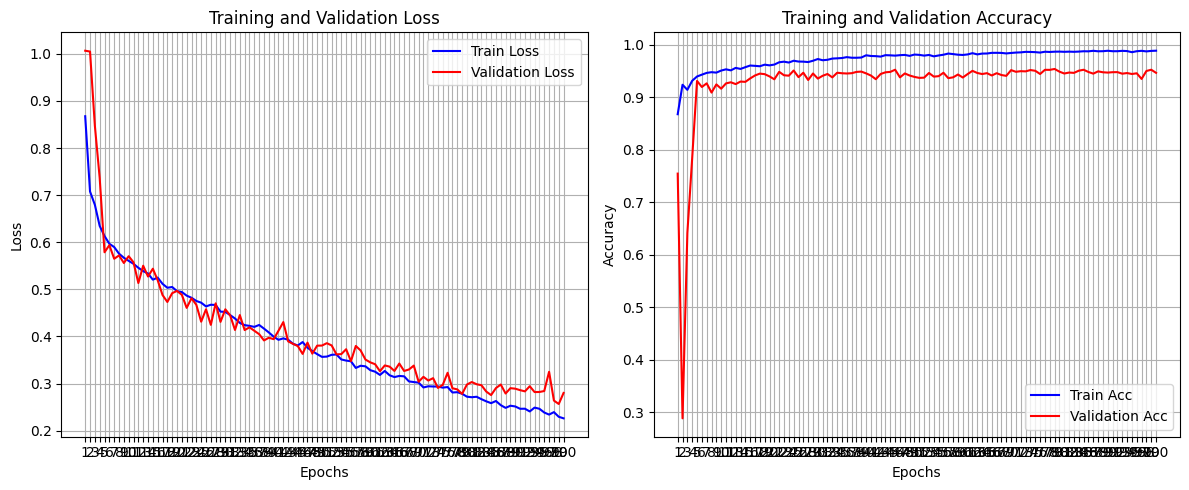

In [26]:
plot_history(res_unetpp_dicebce)

# 4. 성능 비교

In [27]:
def calculate_iou_score(tgt, pred):
    if tgt.shape != pred.shape:
        pred = resize(pred, tgt.shape, mode='constant', preserve_range=True).astype(np.uint8)
    
    intersection = np.logical_and(tgt, pred).sum() 
    union = np.logical_or(tgt, pred).sum()
    iou_score = intersection / (union + 1e-7)
    print(f"IoU: {iou_score:.6f}")
    return iou_score

In [28]:
def get_output(model, preproc, img_path, out_path, label_path=None):
    origin_img = imread(img_path)
    data = {'image': origin_img}
    processed = preproc(**data)
    input_tensor = torch.tensor(processed['image'] / 255., dtype=torch.float32)
    input_tensor = input_tensor.permute(2,0,1).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    # 리스트로 올 경우 마지막(가장 정확한) 결과를 선택
    if isinstance(output, list):
        final_output = output[-1]
    else:
        final_output = output
    pred = (final_output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255 # 흰색으로
    pred = Image.fromarray(pred).convert('L')

    bg = Image.fromarray(origin_img).convert('RGBA')
    pred_resized = pred.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(bg, pred_resized, alpha=0.7)

    blended.save(out_path)

    # PIL 객체를 numpy로 변환
    img_np = np.array(blended)

    # 시각화
    # plt.imshow(img_np)
    # plt.axis('off')  # 축 제거 (옵션)
    # plt.show()

    # tgt = None
    # if label_path:
    #     label_img = imread(label_path)
    #     label_data = {"image": label_img}
    #     label_processed = preproc(**label_data)["image"]
    #     tgt = (label_processed == 7).astype(np.uint8) * 1 # 도로만 1값
    tgt = None
    if label_path:
        label_img = imread(label_path)
        # 라벨 데이터 전처리 (도로 영역 추출)
        # label_processed = preproc(image=label_img)["image"]
        # label_data = {"image": label_img}
        # label_processed = preproc(**label_data)["image"]
        tgt = (label_img == 7).astype(np.uint8) * 255 # 시각화를 위해 255 곱함

        # 2행 1열 구조로 시각화
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))
        
        # 첫 번째 칸: 예측 오버레이
        axes[0].imshow(np.array(blended))
        axes[0].set_title("Prediction Overlay")
        axes[0].axis('off')

        # 두 번째 칸: 정답(Label) 마스크
        axes[1].imshow(tgt, cmap='gray')
        axes[1].set_title("Ground Truth (Label)")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # 다시 원래 값인 0, 1로 복구 (반환용)
        tgt = (tgt / 255).astype(np.uint8)
    else:
        # 라벨이 없을 때는 기존처럼 하나만 출력
        plt.figure(figsize=(10, 6))
        plt.imshow(np.array(blended))
        plt.title("Prediction Overlay")
        plt.axis('off')
        plt.show()

    return blended, np.array(pred), tgt

In [67]:
idx = 3
img_path = DATA_DIR + f"/image_2/00{str(idx).zfill(4)}_10.png"
label_path = DATA_DIR + f'/semantic/00{str(idx).zfill(4)}_10.png'

## 4.1. UNet

In [68]:
loaded_model = UNet(in_chs=3, out_chs=1)
loaded_model.load_state_dict(torch.load(SAVE_DIR + "/best_unet.pt", map_location=torch.device('cpu'))['model_state_dict'])

<All keys matched successfully>

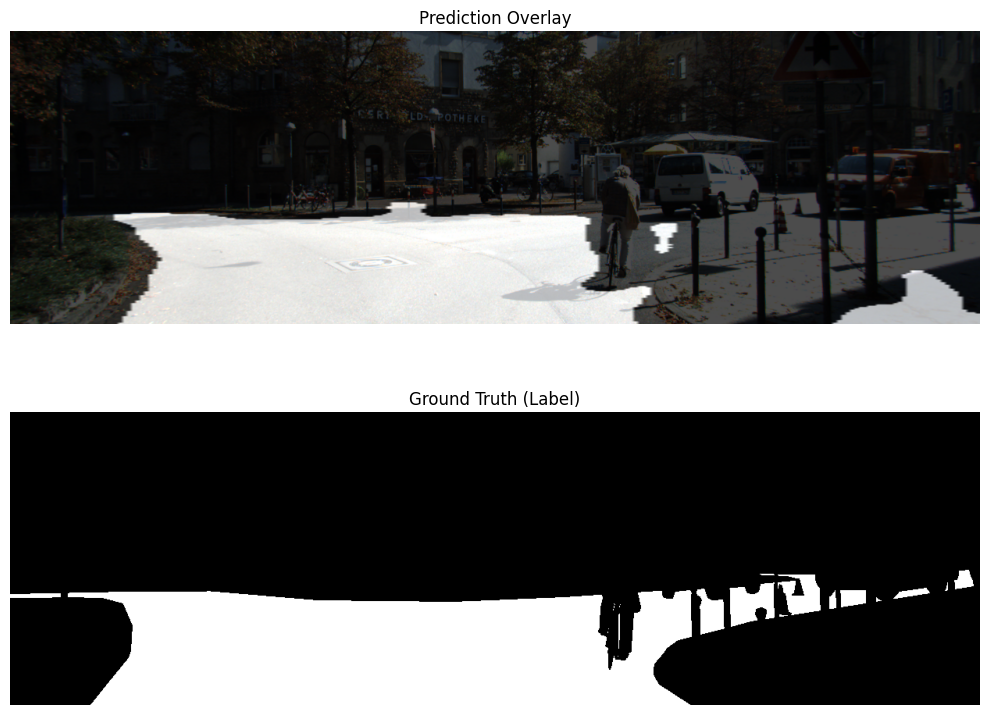

IoU: 0.738389


In [69]:
out_path = f'./result_unet_{str(idx).zfill(3)}.png'

output, pred, tgt = get_output(loaded_model, test_aug, img_path, out_path, label_path)
iou_res = calculate_iou_score(tgt, pred)

## 4.2. UNet++

In [70]:
loaded_model_unetpp_bce = UNetPP(in_chs=3, out_chs=1, deep_supervision=True)
loaded_model_unetpp_bce.load_state_dict(torch.load(SAVE_DIR + "/best_unetpp_bce.pt", map_location=torch.device('cpu'))['model_state_dict'])

<All keys matched successfully>

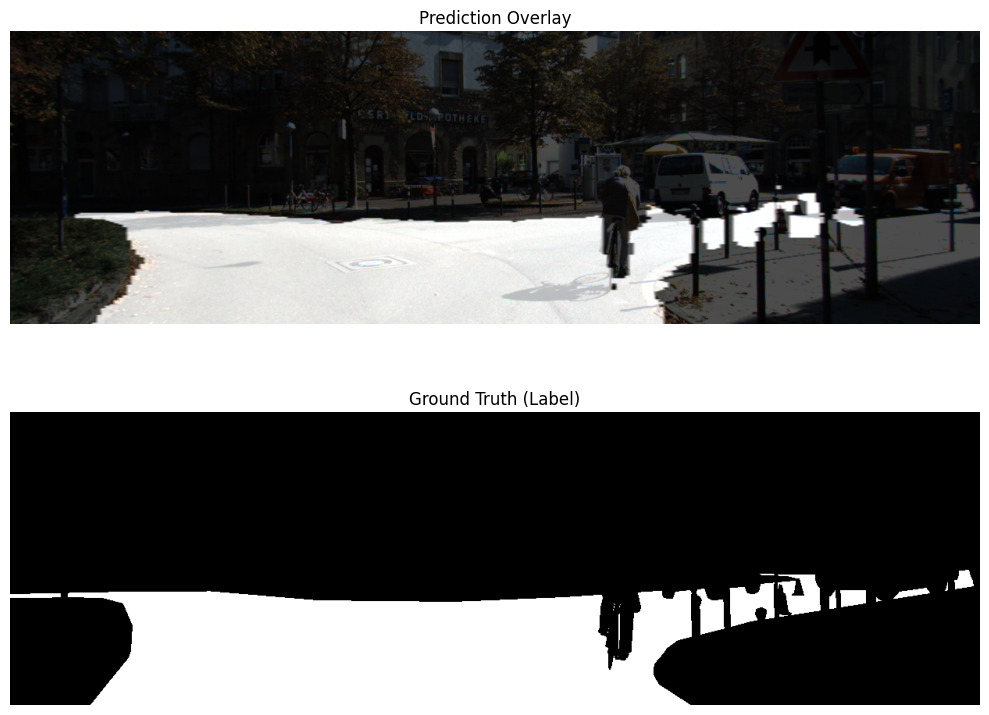

IoU: 0.918767


In [71]:
out_path = f'./result_unetpp_bce_{str(idx).zfill(3)}.png'

output, pred, tgt = get_output(loaded_model_unetpp_bce, test_aug, img_path, out_path, label_path)
iou_res = calculate_iou_score(tgt, pred)

In [72]:
loaded_model_unetpp_dicebce = UNetPP(in_chs=3, out_chs=1, deep_supervision=True)
loaded_model_unetpp_dicebce.load_state_dict(torch.load(SAVE_DIR + "/best_unetpp_dicebce.pt", map_location=torch.device('cpu'))['model_state_dict'])

<All keys matched successfully>

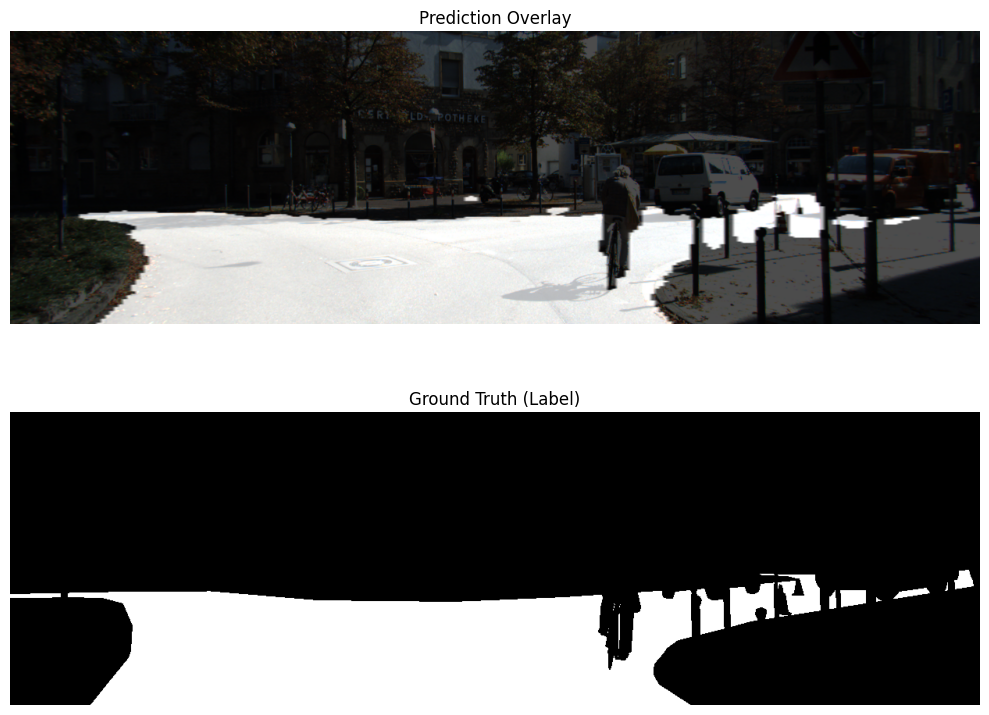

IoU: 0.902668


In [73]:
out_path = f'./result_unetpp__dicebce{str(idx).zfill(3)}.png'

output, pred, tgt = get_output(loaded_model_unetpp_dicebce, test_aug, img_path, out_path, label_path)
iou_res = calculate_iou_score(tgt, pred)

## 4.3. 정량 비교 (mIoU)

In [76]:
def calculate_miou(pred, target, num_classes=1, smooth=1e-6):
    """
    pred: (B, H, W) 또는 (B, 1, H, W) - Threshold(0.5)가 적용된 이진 마스크
    target: (B, H, W) 또는 (B, 1, H, W) - 실제 정답 마스크
    """
    # 차원 맞추기 (B, H, W)
    pred = pred.view(-1)
    target = target.view(-1)

    # Intersection (교집합): 둘 다 1인 영역
    intersection = (pred * target).sum()
    
    # Union (합집합): A + B - 교집합
    total = (pred + target).sum()
    union = total - intersection
    
    # IoU 계산
    iou = (intersection + smooth) / (union + smooth)
    
    return iou.item()

# 여러 배치에 대해 평균을 낼 때 예시
def get_miou_score(model, dataloader, device="cuda"):
    model.eval()
    miou_list = []
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            # 0.5 기준으로 이진화 (Binary Classification 기준)
            if isinstance(outputs, list): # UNet++ Deep Supervision 대응
                outputs = outputs[-1]
            
            preds = (outputs > 0.5).float()
            
            iou = calculate_miou(preds, masks)
            miou_list.append(iou)
            
    return np.mean(miou_list)

In [78]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [83]:
loaded_model = loaded_model.to(device)
test_miou = get_miou_score(loaded_model, test_loader, device)
print(f"Final Test mIoU Score (UNet): {test_miou:.4f}")

Final Test mIoU Score (UNet): 0.7796


In [84]:
loaded_model_unetpp_bce = loaded_model_unetpp_bce.to(device)
test_miou = get_miou_score(loaded_model_unetpp_bce, test_loader, device)
print(f"Final Test mIoU Score (UNet++ with BCE_loss): {test_miou:.4f}")

Final Test mIoU Score (UNet++ with BCE_loss): 0.8367


In [85]:
loaded_model_unetpp_dicebce = loaded_model_unetpp_dicebce.to(device)
test_miou = get_miou_score(loaded_model_unetpp_dicebce, test_loader, device)
print(f"Final Test mIoU Score (UNet++ with DiceBCELoss): {test_miou:.4f}")

Final Test mIoU Score (UNet++ with DiceBCELoss): 0.8157


- 파라미터 수 비교

In [ ]:
# 필터 개수 32개부터 사용
unet_n_parmas = sum([p.numel() for p in model_unet.parameters() if p.requires_grad])
print(unet_n_parmas)
unetpp_n_parmas = sum([p.numel() for p in model_unetpp_bce.parameters() if p.requires_grad])
print(unetpp_n_parmas)

7760097
9163428


In [ ]:
# 필터 개수 32개부터 사용
unet_64 = UNet(3,1,n_filters=[64, 128, 256, 512, 1024])
unetpp_64 = UNetPP(3,1,n_filters=[64, 128, 256, 512, 1024], deep_supervision=True)

In [59]:
unet64_n_parmas = sum([p.numel() for p in unet_64.parameters() if p.requires_grad])
print(unet64_n_parmas)
unetpp64_n_parmas = sum([p.numel() for p in unetpp_64.parameters() if p.requires_grad])
print(unetpp64_n_parmas)

31031745
36629828


# 회고

- UNet++를 짤 때 구조를 lower triangular 형태로 보고, 행렬을 하나 정의해서 각 노드(?)를 해당하는 위치의 인덱스 값으로 불러오는 식으로 설계를 할 수 없을까 했는데, 어려워서 일단 노드를 명시하는 방식으로 짰다. 추후 코드를 더 개선해 봐야겠다.  
- UNet의 필터 개수(차원)이 64부터 시작해서 비교를 위해 UNet++의 필터 개수(차원)도 64부터 지정했는데, 아무래도 중간 계산이 많다 보니 돌아가지 않았다. 공정한 비교를 위해 둘다 초기 필터 개수를 32로 낮췄는데, UNet++의 수렴 결과가 이전보다 훨씬 좋아졌고 UNet 64의 경우를 능가했다.  
&rarr; 공정한 비교를 위해서라지만 UNet의 성능을 끌어내리는 게 아닌가 했는데, 파라미터 수를 비교하면서 UNet++ 32가 UNet 64보다 파라미터 수는 훨씬 적으면서, 성능은 월등히 높다는 것을 확인하여 UNet++의 의미를 확인할 수 있었다.  
- UNet과 UNet++의 학습 속도가 거의 몇 배 차이가 났다. 물론 inference 성능만을 생각했을 때 inference 속도에서 큰 차이가 없다면 IoU가 높은 것이 좋지만, 어떤 모델을 사용할지는 주어진 상황을 고려해서 결정해야 할 것 같다.  